<a href="https://colab.research.google.com/github/Maithilyk5/Impluse_buying_prediction_E-commerce/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# 1. Upload and load data

from google.colab import files


import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/BNPL Dataset/Raw Data_Paylater and Non Paylater User.csv', sep=';')

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
df.head()

Shape: (810, 35)

Columns:
['Gender', 'E-Paylater User Status', 'Educational Background', 'Year of Birth', 'Job Status', 'Monthly Income', 'Average monthly expenditure for online shopping in relation to monthly income', 'IBB1', 'IBB2', 'IBB3', 'IBB4', 'P1', 'P2', 'P3', 'P4', 'SI1', 'SI2', 'SI3', 'SI4', 'SI5', 'SI6', 'H1', 'H2', 'H3', 'H4', 'SC1', 'SC2', 'SC3 ', 'SC4 ', 'SC5', 'NE1', 'NE2', 'NE3', 'NE4', 'NE5']


,Gender,E-Paylater User Status,Educational Background,Year of Birth,Job Status,Monthly Income,Average monthly expenditure for online shopping in relation to monthly income,IBB1,IBB2,IBB3,...,SC1,SC2,SC3,SC4,SC5,NE1,NE2,NE3,NE4,NE5
0,2,1,3,1997,2,3,1,3,3,3,...,5,5,3,3,4,3,3,4,3,2
1,1,2,1,2002,1,2,2,3,1,2,...,4,4,2,3,4,5,5,5,5,4
2,1,1,1,2002,1,2,1,3,3,3,...,4,4,2,2,2,3,3,3,3,3
3,2,2,3,2002,1,1,1,4,4,4,...,2,4,2,2,2,1,1,1,2,1
4,1,2,3,2002,2,6,1,1,1,1,...,5,2,3,1,5,3,3,2,3,3


In [ ]:

# 2. Clean column names

df.columns = (
    df.columns.str.strip()
              .str.replace(r"\s+", "_", regex=True)
              .str.replace("-", "_", regex=False)
              .str.replace("/", "_", regex=False)
              .str.replace("(", "", regex=False)
              .str.replace(")", "", regex=False)
)

print(df.columns.tolist())

['Gender', 'E_Paylater_User_Status', 'Educational_Background', 'Year_of_Birth', 'Job_Status', 'Monthly_Income', 'Average_monthly_expenditure_for_online_shopping_in_relation_to_monthly_income', 'IBB1', 'IBB2', 'IBB3', 'IBB4', 'P1', 'P2', 'P3', 'P4', 'SI1', 'SI2', 'SI3', 'SI4', 'SI5', 'SI6', 'H1', 'H2', 'H3', 'H4', 'SC1', 'SC2', 'SC3', 'SC4', 'SC5', 'NE1', 'NE2', 'NE3', 'NE4', 'NE5']


In [ ]:

# 3. Basic inspection

print(df.info())
print(df.isnull().sum().sort_values(ascending=False).head(20))
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 810 entries, 0 to 809
Data columns (total 35 columns):
 #   Column                                                                         Non-Null Count  Dtype
---  ------                                                                         --------------  -----
 0   Gender                                                                         810 non-null    int64
 1   E_Paylater_User_Status                                                         810 non-null    int64
 2   Educational_Background                                                         810 non-null    int64
 3   Year_of_Birth                                                                  810 non-null    int64
 4   Job_Status                                                                     810 non-null    int64
 5   Monthly_Income                                                                 810 non-null    int64
 6   Average_monthly_expenditure_for_online_sho

,Gender,E_Paylater_User_Status,Educational_Background,Year_of_Birth,Job_Status,Monthly_Income,Average_monthly_expenditure_for_online_shopping_in_relation_to_monthly_income,IBB1,IBB2,IBB3,...,SC1,SC2,SC3,SC4,SC5,NE1,NE2,NE3,NE4,NE5
0,2,1,3,1997,2,3,1,3,3,3,...,5,5,3,3,4,3,3,4,3,2
1,1,2,1,2002,1,2,2,3,1,2,...,4,4,2,3,4,5,5,5,5,4
2,1,1,1,2002,1,2,1,3,3,3,...,4,4,2,2,2,3,3,3,3,3
3,2,2,3,2002,1,1,1,4,4,4,...,2,4,2,2,2,1,1,1,2,1
4,1,2,3,2002,2,6,1,1,1,1,...,5,2,3,1,5,3,3,2,3,3


In [ ]:

# 4. Define target variable


target_col = "E_Paylater_User_Status"
print(df[target_col].value_counts(dropna=False))
df[target_col] = df[target_col].map({1: 0, 2: 1})  # 0=planned, 1=impulse
print("After mapping:", df[target_col].value_counts())

E_Paylater_User_Status
1    606
2    204
Name: count, dtype: int64
After mapping: E_Paylater_User_Status
0    606
1    204
Name: count, dtype: int64


In [ ]:

print("Target distribution (%):")
print(df[target_col].value_counts(normalize=True).round(3))

Target distribution (%):
E_Paylater_User_Status
0    0.748
1    0.252
Name: proportion, dtype: float64


In [ ]:

# 6. Create feature groups

all_cols = df.columns.tolist()

demographic_behavior_cols = [
    "Gender",
    "Educational_Background",
    "Year_of_Birth",
    "Job_Status",
    "Monthly_Income",
    "Average_monthly_expenditure_for_online_shopping_in_relation_to_monthly_income"
]

psychological_cols = [col for col in all_cols if (
    col.startswith("IBB") or
    col.startswith("P") or
    col.startswith("SI") or
    col.startswith("H") or
    col.startswith("SC") or
    col.startswith("NE")
)]

print("Baseline columns:", demographic_behavior_cols)
print("Psychological columns:", psychological_cols)
print("No. of psychological columns:", len(psychological_cols))

Baseline columns: ['Gender', 'Educational_Background', 'Year_of_Birth', 'Job_Status', 'Monthly_Income', 'Average_monthly_expenditure_for_online_shopping_in_relation_to_monthly_income']
Psychological columns: ['IBB1', 'IBB2', 'IBB3', 'IBB4', 'P1', 'P2', 'P3', 'P4', 'SI1', 'SI2', 'SI3', 'SI4', 'SI5', 'SI6', 'H1', 'H2', 'H3', 'H4', 'SC1', 'SC2', 'SC3', 'SC4', 'SC5', 'NE1', 'NE2', 'NE3', 'NE4', 'NE5']
No. of psychological columns: 28


In [ ]:

# 7. Prepare X and y

baseline_cols = [c for c in demographic_behavior_cols if c in df.columns]
enhanced_cols = baseline_cols + [c for c in psychological_cols if c in df.columns]

baseline_df = df[baseline_cols + [target_col]].copy()
enhanced_df = df[enhanced_cols + [target_col]].copy()

baseline_df = baseline_df.dropna()
enhanced_df = enhanced_df.dropna()

X_base = baseline_df.drop(columns=[target_col])
y_base = baseline_df[target_col]

X_enh = enhanced_df.drop(columns=[target_col])
y_enh = enhanced_df[target_col]

print("Baseline shape:", X_base.shape, y_base.shape)
print("Enhanced shape:", X_enh.shape, y_enh.shape)

Baseline shape: (810, 6) (810,)
Enhanced shape: (810, 34) (810,)


In [ ]:

# 8. Train-test split

from sklearn.model_selection import train_test_split

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42, stratify=y_base
)

Xe_train, Xe_test, ye_train, ye_test = train_test_split(
    X_enh, y_enh, test_size=0.2, random_state=42, stratify=y_enh
)

In [ ]:

# 9. Build pipelines

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_base = ColumnTransformer(transformers=[
    ("num", numeric_transformer, Xb_train.columns.tolist())
])

preprocessor_enh = ColumnTransformer(transformers=[
    ("num", numeric_transformer, Xe_train.columns.tolist())
])

In [ ]:

# 10. Define models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [ ]:

# 11. Evaluation function

def evaluate_models(X_train, X_test, y_train, y_test, preprocessor, label):
    results = []

    for name, model in models.items():
        pipe = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        if hasattr(pipe, "predict_proba"):
            y_prob = pipe.predict_proba(X_test)[:, 1]
        else:
            y_prob = None

        result = {
            "Feature_Set": label,
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1_Score": f1_score(y_test, y_pred, zero_division=0),
            "ROC_AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
        }
        results.append(result)

    return pd.DataFrame(results)

In [ ]:

# 12. Run baseline vs enhanced

results_base = evaluate_models(
    Xb_train, Xb_test, yb_train, yb_test, preprocessor_base, "Baseline"
)

results_enh = evaluate_models(
    Xe_train, Xe_test, ye_train, ye_test, preprocessor_enh, "Enhanced"
)

results = pd.concat([results_base, results_enh], ignore_index=True)
results = results.sort_values(["Model", "Feature_Set"])
results

,Feature_Set,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
2,Baseline,Gradient Boosting,0.728395,0.440000,0.268293,0.333333,0.683128
5,Enhanced,Gradient Boosting,0.845679,0.766667,0.560976,0.647887,0.835114
0,Baseline,Logistic Regression,0.759259,0.750000,0.073171,0.133333,0.726870
3,Enhanced,Logistic Regression,0.820988,0.666667,0.585366,0.623377,0.816972
1,Baseline,Random Forest,0.679012,0.358974,0.341463,0.350000,0.621347
4,Enhanced,Random Forest,0.833333,0.850000,0.414634,0.557377,0.820399


In [ ]:

# 13. Compare improvements

pivot_results = results.pivot(index="Model", columns="Feature_Set", values=["Accuracy", "Precision", "Recall", "F1_Score", "ROC_AUC"])
pivot_results

Accuracy           Precision              Recall  \
Feature_Set          Baseline  Enhanced  Baseline  Enhanced  Baseline   
Model                                                                   
Gradient Boosting    0.728395  0.845679  0.440000  0.766667  0.268293   
Logistic Regression  0.759259  0.820988  0.750000  0.666667  0.073171   
Random Forest        0.679012  0.833333  0.358974  0.850000  0.341463   

                               F1_Score             ROC_AUC            
Feature_Set          Enhanced  Baseline  Enhanced  Baseline  Enhanced  
Model                                                                  
Gradient Boosting    0.560976  0.333333  0.647887  0.683128  0.835114  
Logistic Regression  0.585366  0.133333  0.623377  0.726870  0.816972  
Random Forest        0.414634  0.350000  0.557377  0.621347  0.820399

In [ ]:

# 14. Feature importance for Random Forest

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor_enh),
    ("model", RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight="balanced"
    ))
])

rf_pipe.fit(Xe_train, ye_train)

importances = rf_pipe.named_steps["model"].feature_importances_
feature_names = Xe_train.columns.tolist()

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feat_imp.head(20)

,Feature,Importance
11,P2,0.098133
10,P1,0.072599
2,Year_of_Birth,0.049862
16,SI3,0.049149
13,P4,0.048351
14,SI1,0.044247
12,P3,0.039892
4,Monthly_Income,0.037698
7,IBB2,0.031428
19,SI6,0.028150


In [ ]:

# 16. Save outputs

results.to_csv("model_comparison_results.csv", index=False)
feat_imp.to_csv("feature_importance_results.csv", index=False)

print("Files saved successfully.")

Files saved successfully.


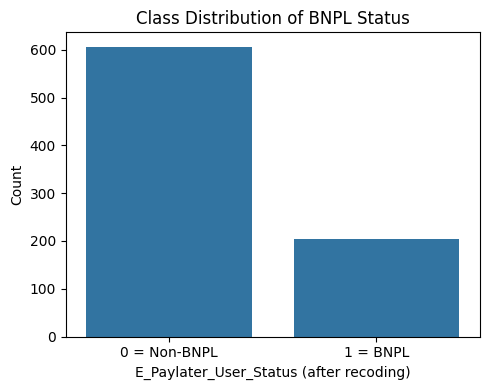

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.countplot(x=df[target_col])
plt.xticks([0, 1], ["0 = Non‑BNPL", "1 = BNPL"])
plt.title("Class Distribution of BNPL Status")
plt.xlabel("E_Paylater_User_Status (after recoding)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

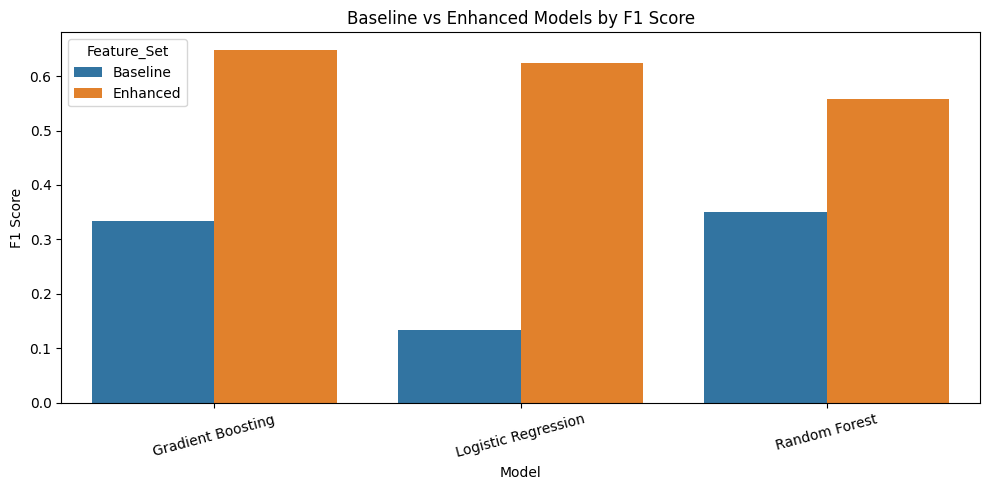

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results, x="Model", y="F1_Score", hue="Feature_Set")
plt.title("Baseline vs Enhanced Models by F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

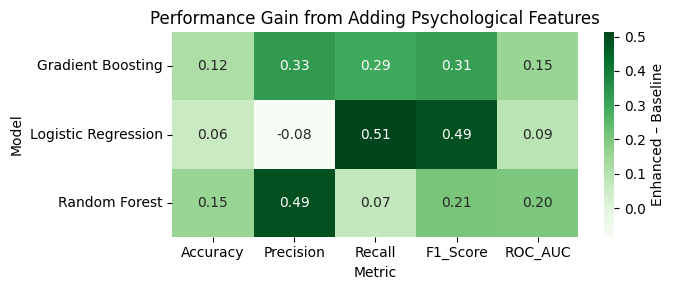

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1_Score", "ROC_AUC"]

# Build DataFrame of metric differences (Enhanced - Baseline)
diff_list = []
for metric in metrics:
    base_vals = results[results["Feature_Set"] == "Baseline"].set_index("Model")[metric]
    enh_vals = results[results["Feature_Set"] == "Enhanced"].set_index("Model")[metric]
    diff = (enh_vals - base_vals).rename(metric)
    diff_list.append(diff)

diff_df = pd.concat(diff_list, axis=1)

plt.figure(figsize=(7, 3))
sns.heatmap(
    diff_df,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    cbar_kws={"label": "Enhanced – Baseline"}
)
plt.title("Performance Gain from Adding Psychological Features")
plt.xlabel("Metric")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

<Figure size 400x400 with 0 Axes>

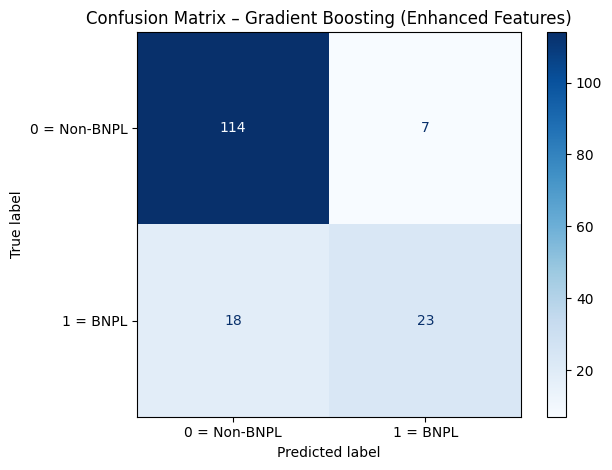

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Reuse trained enhanced Gradient Boosting pipeline
gb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor_enh),
    ("model", models["Gradient Boosting"])
])
gb_pipe.fit(Xe_train, ye_train)

plt.figure(figsize=(4, 4))
ConfusionMatrixDisplay.from_estimator(
    gb_pipe,
    Xe_test,
    ye_test,
    display_labels=["0 = Non‑BNPL", "1 = BNPL"],
    cmap="Blues",
    values_format="d"
)
plt.title("Confusion Matrix – Gradient Boosting (Enhanced Features)")
plt.tight_layout()
plt.show()

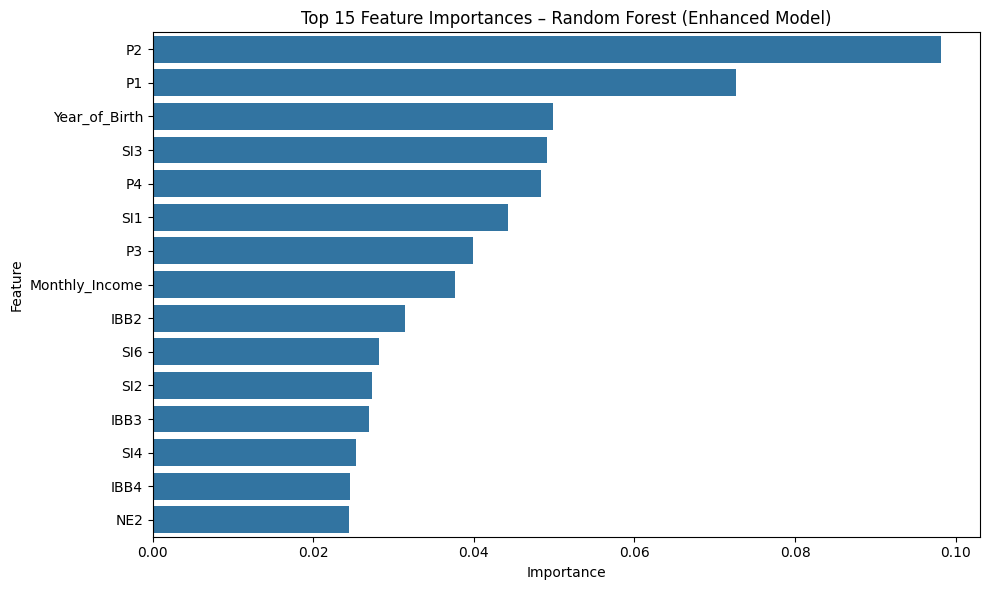

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances – Random Forest (Enhanced Model)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

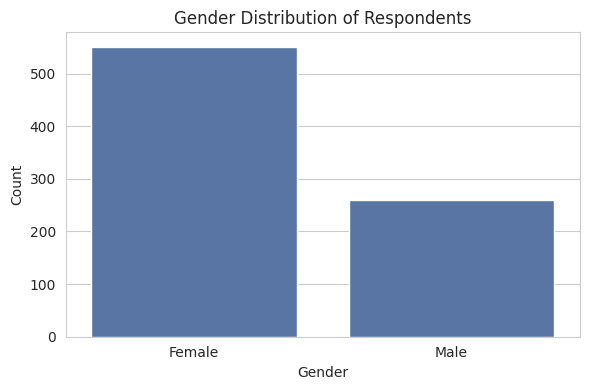

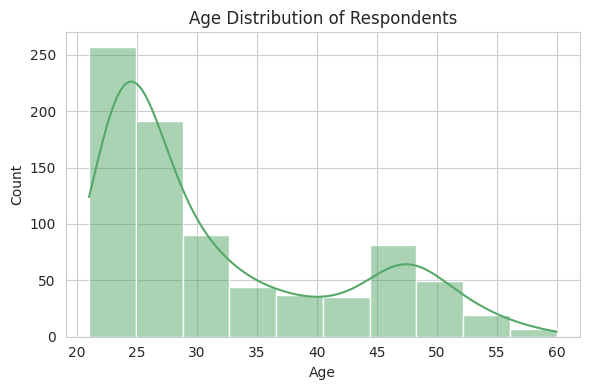

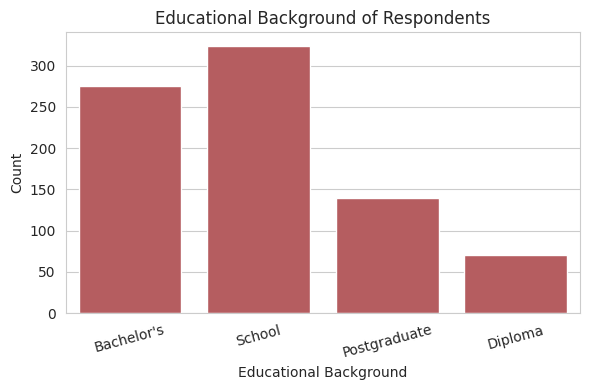

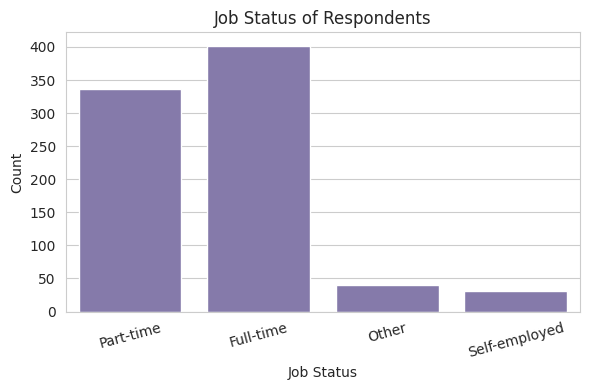

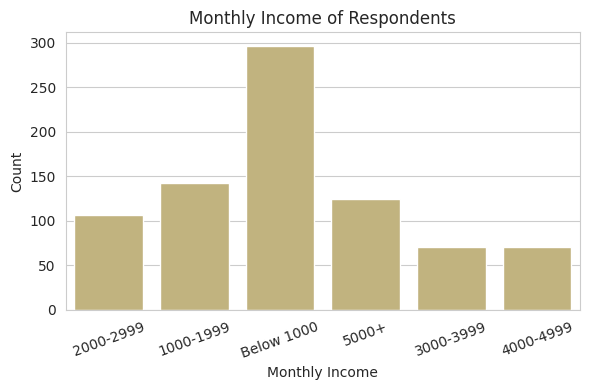

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df["Age"] = 2026 - df["Year_of_Birth"]

gender_labels = {1: "Male", 2: "Female"}
education_labels = {
    1: "School",
    2: "Diploma",
    3: "Bachelor's",
    4: "Postgraduate"
}
job_status_labels = {
    1: "Full-time",
    2: "Part-time",
    3: "Self-employed",
    4: "Other"
}
monthly_income_labels = {
    1: "Below 1000",
    2: "1000-1999",
    3: "2000-2999",
    4: "3000-3999",
    5: "4000-4999",
    6: "5000+"
}

df["Gender_Label"] = df["Gender"].map(gender_labels)
df["Educational_Background_Label"] = df["Educational_Background"].map(education_labels)
df["Job_Status_Label"] = df["Job_Status"].map(job_status_labels)
df["Monthly_Income_Label"] = df["Monthly_Income"].map(monthly_income_labels)

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="Gender_Label", color="#4C72B0", ax=ax)
ax.set_title("Gender Distribution of Respondents")
ax.set_xlabel("Gender")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=df, x="Age", bins=10, kde=True, color="#55A868", ax=ax)
ax.set_title("Age Distribution of Respondents")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="Educational_Background_Label", color="#C44E52", ax=ax)
ax.set_title("Educational Background of Respondents")
ax.set_xlabel("Educational Background")
ax.set_ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="Job_Status_Label", color="#8172B2", ax=ax)
ax.set_title("Job Status of Respondents")
ax.set_xlabel("Job Status")
ax.set_ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="Monthly_Income_Label", color="#CCB974", ax=ax)
ax.set_title("Monthly Income of Respondents")
ax.set_xlabel("Monthly Income")
ax.set_ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
print(df["Gender"].value_counts())
print(df["Educational_Background"].value_counts())
print(df["Job_Status"].value_counts())
print(df["Monthly_Income"].value_counts())
print(df["Age"].describe())

Gender
2    551
1    259
Name: count, dtype: int64
Educational_Background
1    324
3    275
4    140
2     71
Name: count, dtype: int64
Job_Status
1    402
2    337
4     40
3     31
Name: count, dtype: int64
Monthly_Income
1    297
2    143
6    124
3    106
4     70
5     70
Name: count, dtype: int64
count    810.000000
mean      31.888889
std       10.020745
min       21.000000
25%       24.000000
50%       27.000000
75%       39.000000
max       60.000000
Name: Age, dtype: float64


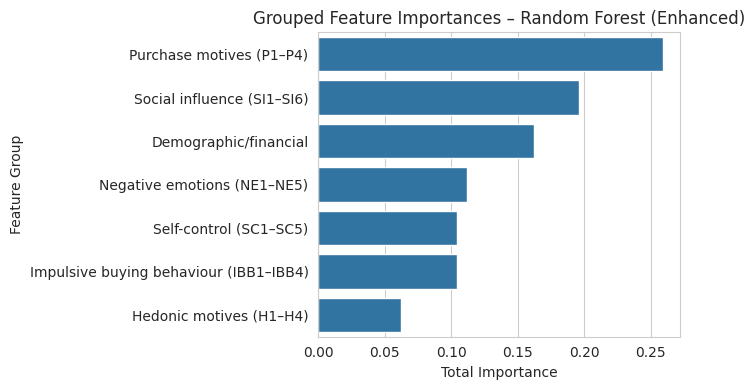

In [ ]:
def feature_group(name):
    if name.startswith("P"):
        return "Purchase motives (P1–P4)"
    if name.startswith("SI"):
        return "Social influence (SI1–SI6)"
    if name.startswith("IBB"):
        return "Impulsive buying behaviour (IBB1–IBB4)"
    if name.startswith("H"):
        return "Hedonic motives (H1–H4)"
    if name.startswith("SC"):
        return "Self-control (SC1–SC5)"
    if name.startswith("NE"):
        return "Negative emotions (NE1–NE5)"
    if name in [
        "Gender",
        "Educational_Background",
        "Year_of_Birth",
        "Job_Status",
        "Monthly_Income",
        "Average_monthly_expenditure_for_online_shopping_in_relation_to_monthly_income",
    ]:
        return "Demographic/financial"
    return "Other"
feat_imp_grouped = feat_imp.copy()
feat_imp_grouped["Group"] = feat_imp_grouped["Feature"].apply(feature_group)
group_importance = (
    feat_imp_grouped.groupby("Group")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
plt.figure(figsize=(7, 4))
sns.barplot(
    data=group_importance,
    x="Importance",
    y="Group",
    color="#1f77b4"
)
plt.title("Grouped Feature Importances – Random Forest (Enhanced)")
plt.xlabel("Total Importance")
plt.ylabel("Feature Group")
plt.tight_layout()
plt.show()

In [ ]:

demographic_characteristics = pd.DataFrame({
    "Variable": [
        "Gender", "Gender",
        "Educational Background", "Educational Background", "Educational Background", "Educational Background",
        "Job Status", "Job Status", "Job Status", "Job Status",
        "Monthly Income", "Monthly Income", "Monthly Income", "Monthly Income", "Monthly Income", "Monthly Income"
    ],
    "Category": [
        "Female", "Male",
        "School", "Bachelor’s", "Postgraduate", "Diploma",
        "Full-time", "Part-time", "Other", "Self-employed",
        "Below 1000", "1000–1999", "2000–2999", "3000–3999", "4000–4999", "5000+"
    ],
    "Frequency": [
        551, 259,
        324, 274, 139, 73,
        399, 337, 39, 35,
        296, 141, 105, 69, 69, 130
    ],
    "Percentage": [
        68.0, 32.0,
        40.0, 33.8, 17.2, 9.0,
        49.3, 41.6, 4.8, 4.3,
        36.5, 17.4, 13.0, 8.5, 8.5, 16.0
    ]
})

print(demographic_characteristics)

demographic_characteristics.to_csv("table_4_1_demographic_characteristics.csv", index=False)
print("CSV exported successfully: table_4_1_demographic_characteristics.csv")

                  Variable       Category  Frequency  Percentage
0                   Gender         Female        551        68.0
1                   Gender           Male        259        32.0
2   Educational Background         School        324        40.0
3   Educational Background     Bachelor’s        274        33.8
4   Educational Background   Postgraduate        139        17.2
5   Educational Background        Diploma         73         9.0
6               Job Status      Full-time        399        49.3
7               Job Status      Part-time        337        41.6
8               Job Status          Other         39         4.8
9               Job Status  Self-employed         35         4.3
10          Monthly Income     Below 1000        296        36.5
11          Monthly Income      1000–1999        141        17.4
12          Monthly Income      2000–2999        105        13.0
13          Monthly Income      3000–3999         69         8.5
14          Monthly Incom